# CISD 43 LAST PROJECT (Analyse FiFa Soccer Player Data)

**Name:**
* Joan Kwon

**Course:** CISD 43 – BIG DATA (Spring, 2026)

### Problem Statement
* This project  focuses on predicting FIFA soccoer player performance using various player statistics. By analyzin g the dataset and applying machine learning techiniques, the goal is to develop a model that can predict player performance, specifically the 'overall_rating', based on dribbling, ball control, acceleration, and sprint speed. 
    
    
    
* **Keywords:** FIFA, soccer, soccer layers, player statistics, soccer player performance, performance prediction, machine learning

### Required packages

* Add instructions to install the required packages


In [171]:
!pip install pymongo

In [172]:
import pandas as pd

### Methodology

1. The methodology involves data preprocessing, exploratory data analysis, and machine learning model implementation.

2. Use tools like pandas for data manipuation, matplotlib and seaborn for visualization, MongoDB for big data analysing and scikit-learn for machine learning.

3. Introduce the topics you used in your project
 * Model 1 - MongoDB
 
 * Model 2 - K Nearest Neighbors (KNN)
 

### Your code starts here

In [173]:
# Connect to MongoDB
from pymongo import MongoClient

In [174]:
# Connect MongoDB to the localhost 27027
client = MongoClient('mongodb://localhost:27017/')

In [175]:
# New Database and Connection has been created. Database name: soccer_db & Connection name: soccer_players
# Access the Database and Collection
db = client.soccer_db
collection = db.soccer_players

In [176]:
# Let's check MongoDB is connected to the Jupyter Notebook. 
try:
    client.admin.command('ping')
    print("Connected to MongoDB!")
except Exception as e:
    print("Connection failed:", e)

Connected to MongoDB!


In [177]:
# Let's display how many documents the data has:
print(collection.count_documents({}))

17954


In [178]:
# Print ONE document to see the real field names
first_doc = collection.find_one()
print(first_doc)

{'_id': ObjectId('6a138bc5d9dcf6111f6bfbd8'), 'name': 'L. Messi', 'full_name': 'Lionel Andrés Messi Cuccittini', 'birth_date': '6/24/1987', 'age': 31, 'height_cm': 170.18, 'weight_kgs': 72.1, 'positions': 'CF,RW,ST', 'nationality': 'Argentina', 'overall_rating': 94, 'potential': 94, 'value_euro': 110500000, 'wage_euro': 565000, 'preferred_foot': 'Left', 'international_reputation(1-5)': 5, 'weak_foot(1-5)': 4, 'skill_moves(1-5)': 4, 'body_type': 'Messi', 'release_clause_euro': 226500000, 'national_team': 'Argentina', 'national_rating': 82, 'national_team_position': 'RF', 'national_jersey_number': 10, 'crossing': 86, 'finishing': 95, 'heading_accuracy': 70, 'short_passing': 92, 'volleys': 86, 'dribbling': 97, 'curve': 93, 'freekick_accuracy': 94, 'long_passing': 89, 'ball_control': 96, 'acceleration': 91, 'sprint_speed': 86, 'agility': 93, 'reactions': 95, 'balance': 95, 'shot_power': 85, 'jumping': 68, 'stamina': 72, 'strength': 66, 'long_shots': 94, 'aggression': 48, 'interceptions': 2

In [179]:
# In one document the real field names are too long and many
# Let's display them

for column in first_doc.keys():
    print(column)

_id
name
full_name
birth_date
age
height_cm
weight_kgs
positions
nationality
overall_rating
potential
value_euro
wage_euro
preferred_foot
international_reputation(1-5)
weak_foot(1-5)
skill_moves(1-5)
body_type
release_clause_euro
national_team
national_rating
national_team_position
national_jersey_number
crossing
finishing
heading_accuracy
short_passing
volleys
dribbling
curve
freekick_accuracy
long_passing
ball_control
acceleration
sprint_speed
agility
reactions
balance
shot_power
jumping
stamina
strength
long_shots
aggression
interceptions
positioning
vision
penalties
composure
marking
standing_tackle
sliding_tackle


#### Query to find players with national_team "Argentina"

In [180]:
query = {"national_team": "Argentina"}
projection = {"_id": 0, "name": 1, "nationality": 1, "overall_rating": 1 }

In [181]:
# Execute the query and limit to the first five record
players = collection.find(query, projection).limit(7)

# Convert to DataFrame
df = pd.DataFrame(list(players))
print(df)

            name nationality  overall_rating
0       L. Messi   Argentina              94
1      S. Agüero   Argentina              89
2      P. Dybala   Argentina              89
3      M. Icardi   Argentina              87
4    G. Lo Celso   Argentina              82
5  R. Funes Mori   Argentina              77
6     R. De Paul   Argentina              77


In [182]:
# Aggregate by nationality and count
pipeline = [
    {"$group": {"_id": "$nationality", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]

results = collection.aggregate(pipeline)

# Convert to DataFrame
df = pd.DataFrame(list(results))
df.rename(columns = {"_id": "nationality", "count": "national_team"}, inplace=False)

# How many Different nationalities
print("Total different nationalities for soccer players data:", len(df))

# How many players per nationality
display(df)

Total different nationalities for soccer players data: 160


,_id,count
0,England,1658
1,Germany,1199
2,Spain,1070
3,France,925
4,Argentina,904
...,...,...
155,Guam,1
156,Nicaragua,1
157,Yemen,1
158,Oman,1


C:\Users\jkwon39\AppData\Local\Temp\ipykernel_33564\1803864151.py:7: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=top20, x="_id", y="count", legend=False, palette="summer")


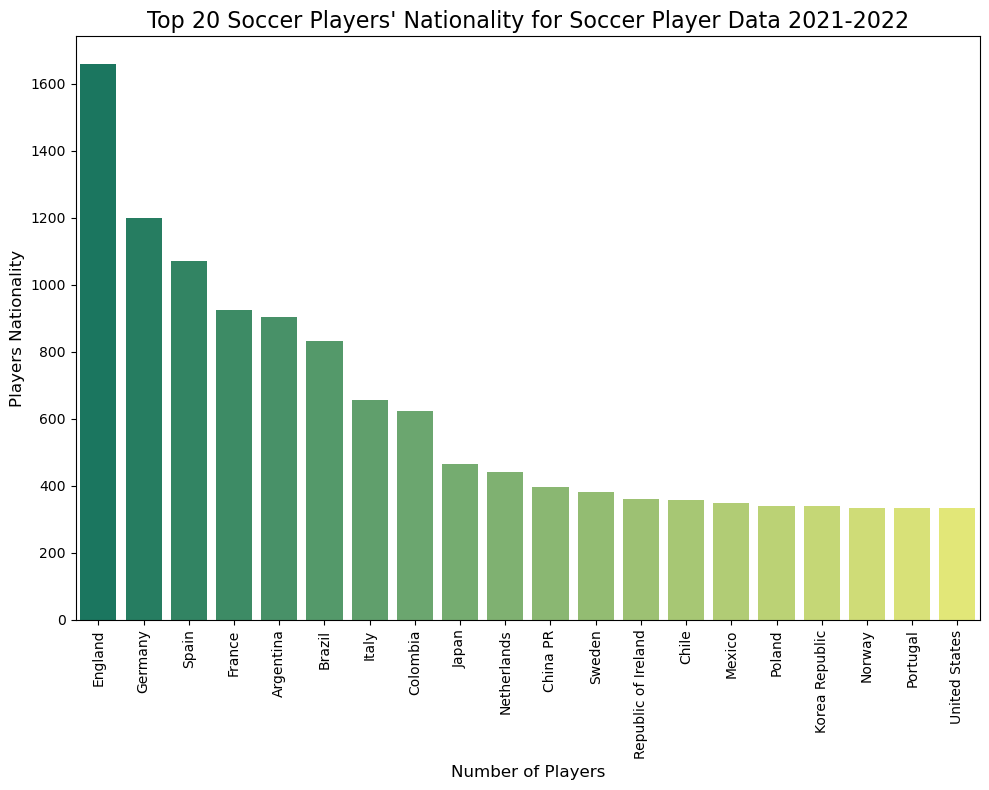

In [183]:
import matplotlib.pyplot as plt
import seaborn as sns

top20 = df.head(20)

plt.figure(figsize=(10,8))
sns.barplot(data=top20, x="_id", y="count", legend=False, palette="summer")
plt.title("Top 20 Soccer Players' Nationality for Soccer Player Data 2021-2022", fontsize=16)
plt.xlabel("Number of Players", fontsize=12)
plt.ylabel("Players Nationality", fontsize=12)
plt.xticks(rotation=90)
plt.tight_layout()
plt.show()


#### Create the WordCloud with the data Nationality and Count

In [184]:
# Install WordCloud
!pip install wordcloud

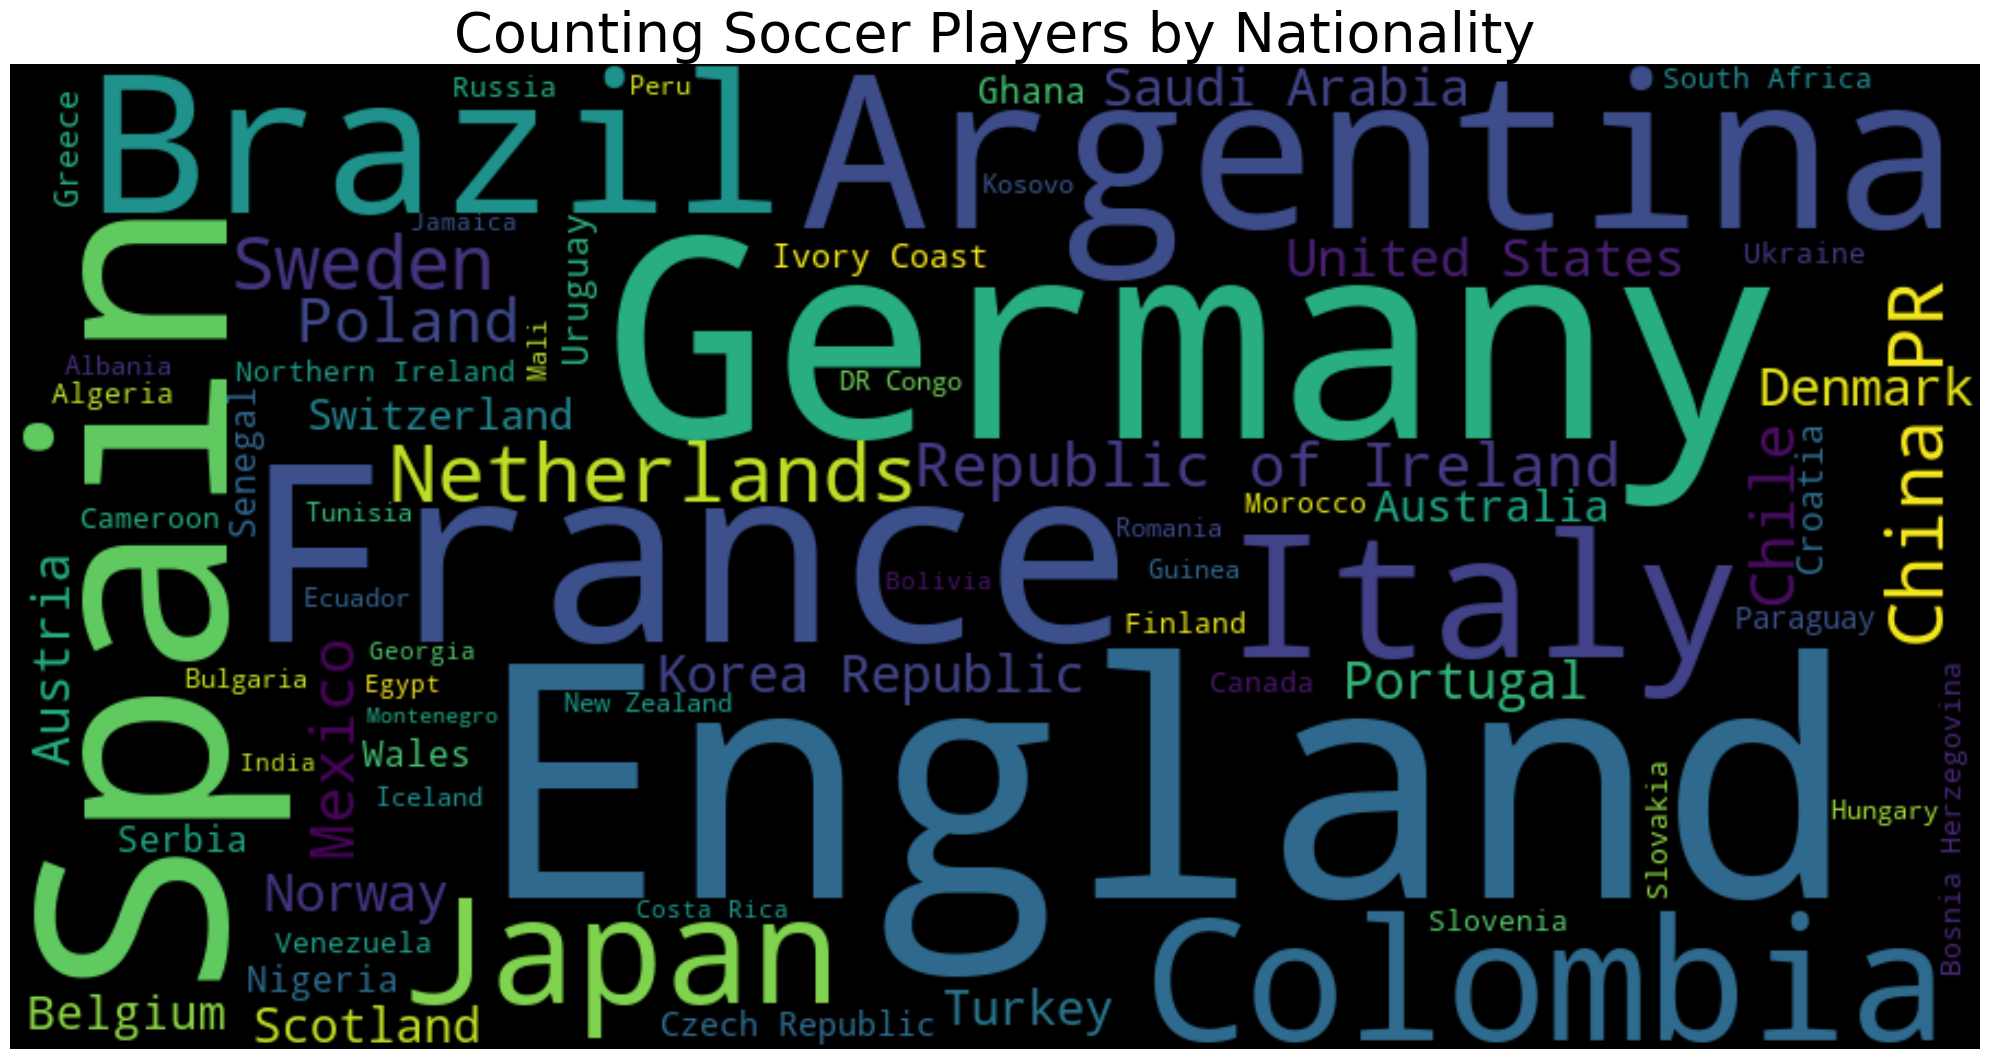

In [188]:
from wordcloud import WordCloud
import matplotlib.pyplot as plt

# Re-run the pipeline again to get new results
# Because MongoDB cursurs can only be read once
pipeline = [
    {"$group": {"_id": "$nationality", "count": {"$sum": 1}}},
    {"$sort": {"count": -1}}
]
results = collection.aggregate(pipeline)

# Rewrite the DataFrame
df = pd.DataFrame(list(results))
df = df.rename(columns = {"_id": "nationality", "count": "national_team"})

# Convert df to dictionary {nationality: count}
nationality_dict = dict(zip(df["nationality"], df["national_team"]))

# Generate WordCloud
wordcloud = WordCloud(
    width=900,
    height=450,
    background_color="Black",
    colormap="viridis",
    max_font_size=150,
    min_font_size=10,
).generate_from_frequencies(nationality_dict)

# Display
plt.figure(figsize=(20,18))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.title("Counting Soccer Players by Nationality", fontsize=40)
plt.tight_layout()
plt.show()

#### Query to find players' nationality and percentage

In [191]:
# Let's find the percentage of each top 20 countries in the data and the percentage of rest of countries together.

# Total soccer counts
total = df["national_team"].sum()

# Add percentage column
df["Percentage"] = (df["national_team"]/ total * 100).round(2)

In [195]:
# Split Top 20 countries and rest of countries
top20 = df.head(20).copy()
rest = pd.DataFrame({
    "natioanlity": ["Rest of Countries"],
    "national_team": [df.iloc[20:]["nationality"].sum()],
    "Percentage": [df.iloc[20:]["Percentage"].sum().round(2)]
})

# Combine Top 20 countries and rest of countries
final_df = pd.concat([top20, rest], ignore_index=True)

print(f"Total Players: {total}")
print(f"Total Nationlities: {len(df)}\n")
display(final_df)

Total Players: 17954
Total Nationlities: 160



,nationality,national_team,Percentage,natioanlity
0,England,1658,9.23,NaN
1,Germany,1199,6.68,NaN
2,Spain,1070,5.96,NaN
3,France,925,5.15,NaN
4,Argentina,904,5.04,NaN
5,Brazil,832,4.63,NaN
6,Italy,655,3.65,NaN
7,Colombia,624,3.48,NaN
8,Japan,466,2.60,NaN
9,Netherlands,441,2.46,NaN


#### Retrieve players who play in a specific position: "CF" (Center Forward), "RW" (Right Winger), "ST" (Striker)

In [196]:
# Limit the players the first 10 CF, ST, RW position
# Use "$in" operator in multiple values in one query

query = {"positions": {"$in": ["CF", "RW", "ST"]}}
projection = {"_id": 0, "name": 1, "nationality": 1, "overall_rating": 1, "positions": 1}

# Convert the result in DataFrame
df = pd.DataFrame(list(collection.find(query, projection)))

# Display separate table for each position

for positions in ["CF", "RW", "ST"]:
    print(f"\n================== {positions} Players ===================")
    position_df = df[df["positions"] == positions].sort_values("overall_rating", ascending=False)
    display(position_df)


================== CF Players ===================


,name,positions,nationality,overall_rating
1802,L. Stindl,CF,Germany,81
1184,M. Sema,CF,Sweden,66
1154,David Haro,CF,Spain,65
368,André Anderson,CF,Brazil,63
959,M. Salas,CF,Argentina,63
428,M. Chajia,CF,Belgium,60
431,N. Mbouhom,CF,Cameroon,60
772,O. Vojić,CF,Austria,59
726,C. Akono,CF,Germany,57
643,P. Almqvist,CF,Sweden,55



================== RW Players ===================


,name,positions,nationality,overall_rating
7,Malcom,RW,Brazil,82
1804,E. Salvio,RW,Argentina,81
1780,S. Berghuis,RW,Netherlands,79
1672,Renatinho,RW,Brazil,74
1680,Hélder Costa,RW,Portugal,74
...,...,...,...,...
594,L. McCarron,RW,England,53
593,M. Bildøy,RW,Norway,53
527,A. Kräuchi,RW,Switzerland,52
539,Cao Sheng,RW,China PR,51



================== ST Players ===================


,name,positions,nationality,overall_rating
1830,L. Suárez,ST,Uruguay,91
1829,H. Kane,ST,England,90
1828,R. Lewandowski,ST,Poland,90
1,E. Cavani,ST,Uruguay,89
0,S. Agüero,ST,Argentina,89
...,...,...,...,...
547,M. Djabi,ST,England,48
545,N. Yahaya,ST,Nigeria,48
546,T. Clare,ST,England,48
544,N. Christoffersson,ST,Sweden,47


#### Retrieve players the first 10 overall_rating players

In [197]:
# limit the players the first 10 overall_rating players

query = {"overall_rating": {"$gte": 90}}
projection = {"_id": 0, "name": 1, "age": 1, "nationality": 1, "overall_rating": 1}
players = collection.find(query, projection).limit(10)
df = pd.DataFrame(list(players))
display(df)

,name,age,nationality,overall_rating
0,L. Messi,31,Argentina,94
1,G. Chiellini,34,Italy,90
2,Sergio Ramos,32,Spain,90
3,David Silva,33,Spain,90
4,D. Godín,33,Uruguay,90
5,T. Kroos,29,Germany,90
6,R. Lewandowski,30,Poland,90
7,J. Oblak,26,Slovenia,90
8,H. Kane,25,England,90
9,L. Suárez,32,Uruguay,91


#### Retrieve Top 10 overall_rating players 

In [198]:
# Find players to make sort top 10 overall_rating players
players = collection.find({}, projection).sort("overall_rating", -1).limit(10)
for player in players:
    print(player)

{'name': 'Cristiano Ronaldo', 'age': 34, 'nationality': 'Portugal', 'overall_rating': 94}
{'name': 'L. Messi', 'age': 31, 'nationality': 'Argentina', 'overall_rating': 94}
{'name': 'Neymar Jr', 'age': 27, 'nationality': 'Brazil', 'overall_rating': 92}
{'name': 'K. De Bruyne', 'age': 27, 'nationality': 'Belgium', 'overall_rating': 91}
{'name': 'E. Hazard', 'age': 28, 'nationality': 'Belgium', 'overall_rating': 91}
{'name': 'De Gea', 'age': 28, 'nationality': 'Spain', 'overall_rating': 91}
{'name': 'L. Modrić', 'age': 33, 'nationality': 'Croatia', 'overall_rating': 91}
{'name': 'L. Suárez', 'age': 32, 'nationality': 'Uruguay', 'overall_rating': 91}
{'name': 'T. Kroos', 'age': 29, 'nationality': 'Germany', 'overall_rating': 90}
{'name': 'R. Lewandowski', 'age': 30, 'nationality': 'Poland', 'overall_rating': 90}


#### Retrieve players with International Reputation rating of 5

In [199]:
# Retrieve players whoes International Reputation rate is 5
query = {"international_reputation(1-5)": 5}
projection = {"_id": 0, "name": 1, "nationality": 1, "overall_rating": 1, "international_reputation": 1}
players = collection.find(query, projection)
for player in players:
    print(player)

{'name': 'L. Messi', 'nationality': 'Argentina', 'overall_rating': 94}
{'name': 'M. Neuer', 'nationality': 'Germany', 'overall_rating': 89}
{'name': 'Z. Ibrahimović', 'nationality': 'Sweden', 'overall_rating': 85}
{'name': 'L. Suárez', 'nationality': 'Uruguay', 'overall_rating': 91}
{'name': 'Neymar Jr', 'nationality': 'Brazil', 'overall_rating': 92}
{'name': 'Cristiano Ronaldo', 'nationality': 'Portugal', 'overall_rating': 94}


#### Retrieve players who is younger than 29 & older than 40

In [200]:
# Retrieve players who is youner than 29
query = {"age": {"$lt": 29}}
projection = {"_id": 0, "name": 1, "nationality": 1, "overall_rating": 1, "age": 1}
players = collection.find(query, projection).limit(10)
for player in players:
    print(player)

{'name': 'C. Eriksen', 'age': 27, 'nationality': 'Denmark', 'overall_rating': 88}
{'name': 'P. Pogba', 'age': 25, 'nationality': 'France', 'overall_rating': 88}
{'name': 'L. Insigne', 'age': 27, 'nationality': 'Italy', 'overall_rating': 88}
{'name': 'K. Koulibaly', 'age': 27, 'nationality': 'Senegal', 'overall_rating': 88}
{'name': 'V. van Dijk', 'age': 27, 'nationality': 'Netherlands', 'overall_rating': 88}
{'name': 'K. Mbappé', 'age': 20, 'nationality': 'France', 'overall_rating': 88}
{'name': 'T. Courtois', 'age': 26, 'nationality': 'Belgium', 'overall_rating': 89}
{'name': 'M. ter Stegen', 'age': 26, 'nationality': 'Germany', 'overall_rating': 89}
{'name': 'A. Griezmann', 'age': 27, 'nationality': 'France', 'overall_rating': 89}
{'name': 'M. Salah', 'age': 26, 'nationality': 'Egypt', 'overall_rating': 89}


In [201]:
query = {"age": {"$gt": 40}}
projection = {"_id": 0, "name": 1, "nationality": 1, "overall_rating": 1, "age": 1}
players = collection.find(query, projection).limit(10)
for player in players:
    print(player)

{'name': 'Hilton', 'age': 41, 'nationality': 'Brazil', 'overall_rating': 78}
{'name': 'S. Bertoli', 'age': 41, 'nationality': 'Argentina', 'overall_rating': 73}
{'name': 'O. Pérez', 'age': 46, 'nationality': 'Mexico', 'overall_rating': 71}
{'name': 'K. Pilkington', 'age': 45, 'nationality': 'England', 'overall_rating': 48}
{'name': 'T. Warner', 'age': 44, 'nationality': 'Trinidad & Tobago', 'overall_rating': 53}
{'name': 'A. Al Basisi', 'age': 41, 'nationality': 'Saudi Arabia', 'overall_rating': 56}
{'name': 'P. van der Vlag', 'age': 41, 'nationality': 'Netherlands', 'overall_rating': 58}
{'name': 'M. Tyler', 'age': 41, 'nationality': 'England', 'overall_rating': 59}
{'name': 'H. Sulaimani', 'age': 42, 'nationality': 'Saudi Arabia', 'overall_rating': 64}
{'name': 'F. Kippe', 'age': 41, 'nationality': 'Norway', 'overall_rating': 65}


#### Retrieve players who is most youngest and most oldest

In [202]:
# Retrieve players who is the youngest and the oldest in the data with .sort()

youngest_player = collection.find({}, projection).sort("age", 1).limit(1)
oldest_player = collection.find({}, projection).sort("age", -1).limit(1)

print("The Youngest Player is:")
for player in youngest_player:
    print(player)

print("\nThe Oldest Player is:")
for player in oldest_player:
    print(player)

The Youngest Player is:
{'name': 'Y. Verschaeren', 'age': 17, 'nationality': 'Belgium', 'overall_rating': 68}

The Oldest Player is:
{'name': 'O. Pérez', 'age': 46, 'nationality': 'Mexico', 'overall_rating': 71}


#### Retrieve players who have "Left Foot" as their preferred foot.

In [203]:
query = {"preferred_foot": "Left"}
projection = {"_id":0, "name": 1, "nationality": 1, "preferred_foot": 1, "overall_rating": 1}

players = collection.find(query, projection).limit(5)
df = pd.DataFrame(players)
display(df)

,name,nationality,overall_rating,preferred_foot
0,L. Messi,Argentina,94,Left
1,T. Courtois,Belgium,89,Left
2,A. Griezmann,France,89,Left
3,M. Salah,Egypt,89,Left
4,P. Dybala,Argentina,89,Left


In [204]:
# Find players to make sort top 10 overall_rating players
projection = {"_id": 0, "name": 1, "age": 1, "overall_rating": 1, "heading_accuracy": 1, "short_passing": 1, "dribbling": 1, "curve": 1, "feekick_accuracy": 1, "long_passing": 1,"ball_control": 1, "sprint_speed": 1, "shot_power": 1,"jumping": 1, "stamina": 1, "strength": 1, "long_shots": 1, "interceptions": 1, "vision": 1}
players = collection.find({}, projection).sort("overall_rating", -1).limit(10)

df = pd.DataFrame(players)
display(df)

,name,age,overall_rating,heading_accuracy,short_passing,dribbling,curve,long_passing,ball_control,sprint_speed,shot_power,jumping,stamina,strength,long_shots,interceptions,vision
0,Cristiano Ronaldo,34,94,89,81,88,81,77,94,91,95,95,88,79,93,29,82
1,L. Messi,31,94,70,92,97,93,89,96,86,85,68,72,66,94,22,94
2,Neymar Jr,27,92,62,84,96,88,80,95,90,80,61,81,49,82,36,88
3,K. De Bruyne,27,91,55,92,86,85,91,91,76,91,63,89,75,91,61,94
4,E. Hazard,28,91,61,89,95,83,83,94,88,82,56,83,66,80,41,89
5,De Gea,28,91,21,50,18,21,51,38,58,31,67,43,64,12,30,68
6,L. Modrić,33,91,55,93,90,85,88,92,72,79,68,89,58,82,83,92
7,L. Suárez,32,91,82,82,86,86,69,88,73,86,69,90,83,85,41,84
8,T. Kroos,29,90,58,92,81,86,93,90,62,87,30,75,73,89,76,90
9,R. Lewandowski,30,90,85,83,85,77,65,89,78,88,84,78,84,84,39,77


### K-Nearest Neighbors Machine Learning

In [2]:
# Import required libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay, classification_report
from sklearn.metrics import mean_squared_error
%matplotlib inline

In [3]:
# Load dataset
df = pd.read_csv('fifa_players.csv')

In [5]:
df.head()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
0,L. Messi,Lionel Andrés Messi Cuccittini,6/24/1987,31,170.18,72.1,"CF,RW,ST",Argentina,94,94,...,94,48,22,94,94,75,96,33,28,26
1,C. Eriksen,Christian Dannemann Eriksen,2/14/1992,27,154.94,76.2,"CAM,RM,CM",Denmark,88,89,...,89,46,56,84,91,67,88,59,57,22
2,P. Pogba,Paul Pogba,3/15/1993,25,190.50,83.9,"CM,CAM",France,88,91,...,82,78,64,82,88,82,87,63,67,67
3,L. Insigne,Lorenzo Insigne,6/4/1991,27,162.56,59.0,"LW,ST",Italy,88,88,...,84,34,26,83,87,61,83,51,24,22
4,K. Koulibaly,Kalidou Koulibaly,6/20/1991,27,187.96,88.9,CB,Senegal,88,91,...,15,87,88,24,49,33,80,91,88,87


In [6]:
df.tail()

,name,full_name,birth_date,age,height_cm,weight_kgs,positions,nationality,overall_rating,potential,...,long_shots,aggression,interceptions,positioning,vision,penalties,composure,marking,standing_tackle,sliding_tackle
17949,R. McKenzie,Rory McKenzie,10/7/1993,25,175.26,74.8,"RM,CAM,CM",Scotland,67,70,...,54,69,41,60,64,63,56,40,20,18
17950,M. Sipľak,Michal Sipľak,2/2/1996,23,182.88,79.8,LB,Slovakia,59,67,...,22,62,55,42,39,32,52,53,64,60
17951,J. Bekkema,Jan Bekkema,4/9/1996,22,185.42,89.8,GK,Netherlands,59,67,...,9,27,10,5,25,16,47,9,12,13
17952,A. Al Yami,Abdulrahman Al Yami,6/19/1997,21,175.26,64.9,"ST,LM",Saudi Arabia,59,71,...,58,38,15,54,52,50,53,16,18,17
17953,Júnior Brumado,José Francisco dos Santos Júnior,5/15/1999,19,190.50,79.8,ST,Brazil,59,75,...,53,67,20,53,49,52,45,23,31,21


In [11]:
df.columns

Index(['name', 'full_name', 'birth_date', 'age', 'height_cm', 'weight_kgs',
       'positions', 'nationality', 'overall_rating', 'potential', 'value_euro',
       'wage_euro', 'preferred_foot', 'international_reputation(1-5)',
       'weak_foot(1-5)', 'skill_moves(1-5)', 'body_type',
       'release_clause_euro', 'national_team', 'national_rating',
       'national_team_position', 'national_jersey_number', 'crossing',
       'finishing', 'heading_accuracy', 'short_passing', 'volleys',
       'dribbling', 'curve', 'freekick_accuracy', 'long_passing',
       'ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions',
       'balance', 'shot_power', 'jumping', 'stamina', 'strength', 'long_shots',
       'aggression', 'interceptions', 'positioning', 'vision', 'penalties',
       'composure', 'marking', 'standing_tackle', 'sliding_tackle'],
      dtype='object')

In [9]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17954 entries, 0 to 17953
Data columns (total 51 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   name                           17954 non-null  object 
 1   full_name                      17954 non-null  object 
 2   birth_date                     17954 non-null  object 
 3   age                            17954 non-null  int64  
 4   height_cm                      17954 non-null  float64
 5   weight_kgs                     17954 non-null  float64
 6   positions                      17954 non-null  object 
 7   nationality                    17954 non-null  object 
 8   overall_rating                 17954 non-null  int64  
 9   potential                      17954 non-null  int64  
 10  value_euro                     17954 non-null  float64
 11  wage_euro                      17954 non-null  float64
 12  preferred_foot                 17954 non-null 

In [4]:
# Let's fill the missing values with the mean of the numeric columns
numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].mean())

#### Visualizations
##### Visualization help in understanding the distribution and relationships within the dataset
- Plotting the age distribution of payers shows the spread and frequency of different ages, while plotting the relationship between overall 
rating and potential reveals how these two important metircs are related. 
- Plotting a histogram of features helps in learing the distribution of key players attiributes such as age, height, weight, crossing, 
finishing, short passing, dribbling, ball control, acceleration, and sprint speed. This helps in understanding the spread and frequency of 
these attributes among the players.
-Additionally, scatter plots help in learning about the relationships and potential correlations between each feature(e.g., age, height, 
weight, crossing, finishing, etc.) and the target variable(overall rating), revealing how each player attribute mighty influence the overall
player rating.

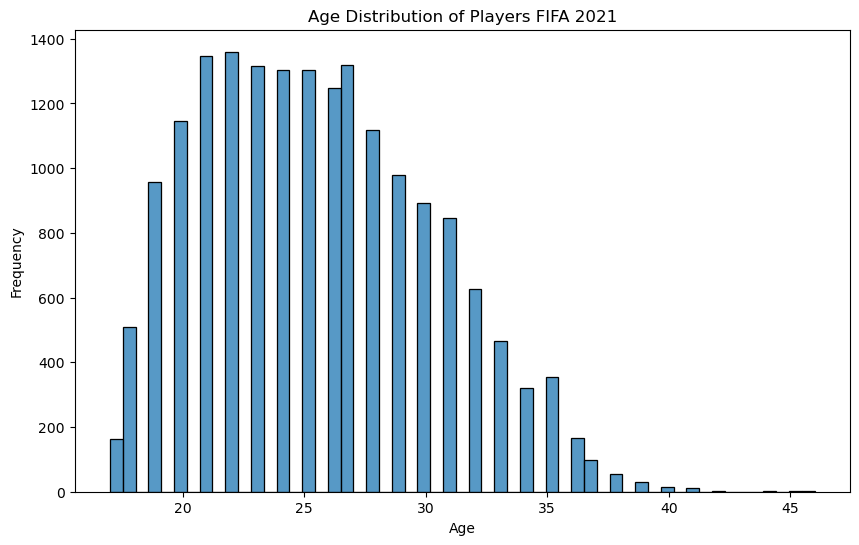

In [14]:
# The age distribution of players in data FIFA 2021
plt.figure(figsize=(10,6))
sns.histplot(df['age'])
plt.title("Age Distribution of Players FIFA 2021")
plt.xlabel("Age")
plt.ylabel("Frequency")
plt.show()

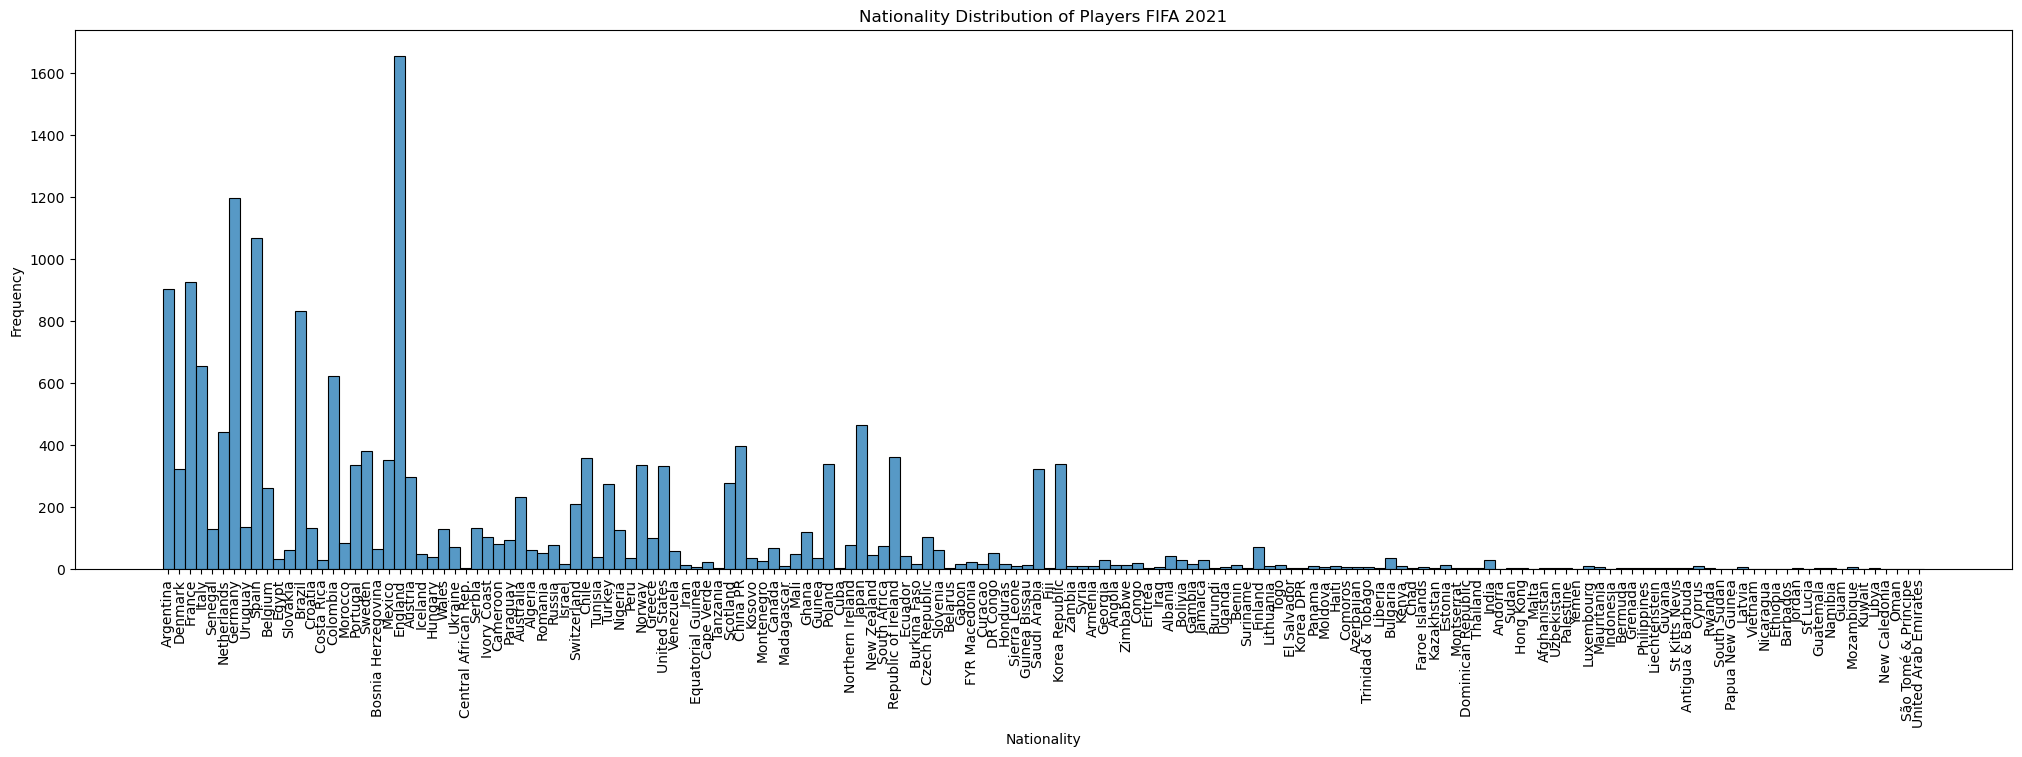

In [20]:
plt.figure(figsize=(25,7))
sns.histplot(df['nationality'])
plt.title("Nationality Distribution of Players FIFA 2021")
plt.xlabel("Nationality")
plt.ylabel("Frequency")
plt.xticks(rotation=90)
plt.show()

<Figure size 1500x800 with 0 Axes>

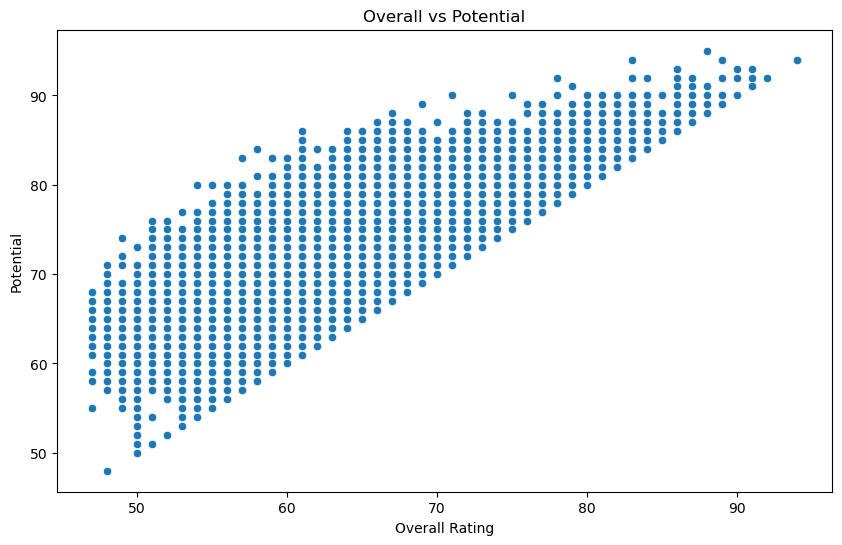

In [26]:
# Plotting the relationship between overall rating and potential
plt.figure(figsize=(10,6))
sns.scatterplot(data=df, x="overall_rating", y="potential")
plt.title("Overall vs Potential")
plt.xlabel("Overall Rating")
plt.ylabel("Potential")
plt.show()

### Machine Learning
- K-Neareast Neighbors(KNN)
- Linear Regression
In this anlysis, two models are being used: the K-Nearest Neighbors(KNN) classifier and Linear Regression. The KNN classifier is used to categorize player ratings into discrete classes performance. Lnear Regression is used to predict the overall player rating as a continuous help in understanding both categorical and continuous aspects of player performance prediction.

In [99]:
#Load the data into a pandas DataFrame
data = pd.read_csv('fifa_players.csv')

# Select relevant features and target variable
features = ['age', 'height_cm', 'weight_kgs', 'crossing', 'finishing','heading_accuracy', 'short_passing', 'volleys','dribbling', 'curve', 
            'freekick_accuracy', 'long_passing','ball_control', 'acceleration', 'sprint_speed', 'agility', 'reactions','balance', 'shot_power',
            'jumping', 'stamina', 'strength', 'long_shots','aggression', 'interceptions', 'positioning', 'vision', 'penalties','composure', 
            'marking', 'standing_tackle', 'sliding_tackle']
target = 'overall_rating'

X = data[features]
y = data[target]

#### Top Ten features in Data visualization

In [118]:
# Select only numeric columns
numeric_df = df.select_dtypes(include=['number'])

# Correlation with overall_rating
correlations = numeric_df.corr()['overall_rating']

# Remove overall_rating itself
correlations = correlations.drop('overall_rating')

# Sort by strongest positive correlation
top_10_correlations = correlations.sort_values(ascending=False).head(10)

# Display the top 10
print(top_10_correlations)

reactions                        0.855767
composure                        0.729278
potential                        0.647249
value_euro                       0.627409
release_clause_euro              0.591957
wage_euro                        0.574453
short_passing                    0.506819
vision                           0.506812
long_passing                     0.489998
international_reputation(1-5)    0.489416
Name: overall_rating, dtype: float64


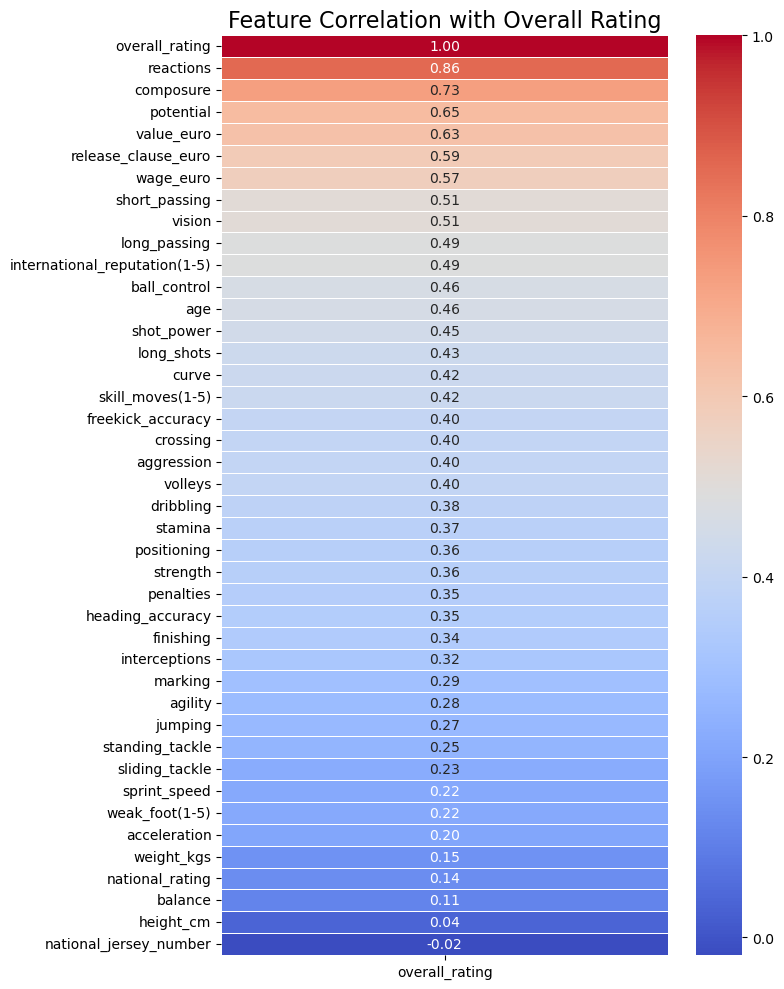

In [125]:
# Let's visualize the top 10 features which has high correlation with overall_rating
# import required libraries
# Then add target to features for correlation
import seaborn as sns
import matplotlib.pyplot as plt

corr_matrix = numeric_df.corr()

# Let's display Plot heatmap
plt.figure(figsize=(8,10))
sns.heatmap(
    corr_matrix[['overall_rating']].sort_values('overall_rating', ascending=False),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    linewidth=0.7
)
plt.title("Feature Correlation with Overall Rating", fontsize=16)
plt.tight_layout()
plt.show()

In [106]:
# Now we know Top 10 rlevant features with target variable - ['reactions', 'composure', 'short_passing', 'vision', 'long_passing','ball_control', 'age', 'shot_power','long_shots', 'curve']
# Reload the features and target to Machine Learning. 
# Use KNN Regression instead of KNN Classification to predict the plyer's rating as a number.
# Then evaluate the model using MAE, MSE, RMSE, or R-squared instead of a classification report.

data = pd.read_csv('fifa_players.csv')

# Select Top 13 relevant features and target variable
features = ['reactions', 'composure', 'short_passing', 'vision', 'long_passing', 'ball_control', 'age', 'shot_power', 'long_shots', 'curve']
target = 'overall_rating'

X = data[features]
y = data[target]

#### KNN Regressor & Train Test Split

In [112]:
# import the required library to standa#rdize feature values to the same scale
# Create an instance of StandardScaler
# Use KNeighborsRegressor to predict players rate by number
# Evaluate the model using MAE, MSE, RMSE, or R-squared

import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn. neighbors import KNeighborsRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

scaler = StandardScaler()
x_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

knn = KNeighborsRegressor(n_neighbors=5)
knn.fit(X_train, y_train)

pred = knn.predict(X_test)

print("MAE", mean_absolute_error(y_test, pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, pred)))
print("R-squard:", r2_score(y_test, pred))

MAE 2.0979114452798666
RMSE 2.737419770666425
R-squard: 0.8500618864564496


In [114]:
# Use this scaled features to recreate a only numeric and standarized features and call the DataFrame method to display them in DataFrame. 
df_features = pd.DataFrame(X_scaled)
df_features.head()

,0,1,2,3,4,5,6,7,8,9
0,3.655821,3.210247,2.249510,2.867672,2.356027,2.238551,1.710590,2.185336,2.527553,1.154918
1,2.884507,2.522088,2.182228,2.655742,2.356027,1.942259,1.652956,1.504400,1.814731,0.304863
2,2.223381,2.436068,1.845817,2.443813,2.420874,1.883000,1.998761,1.661539,1.509235,-0.120165
3,2.333569,2.091988,1.778535,2.373169,1.642720,2.060775,1.134248,1.818678,1.611067,0.304863
4,2.223381,1.833928,0.634737,-0.311272,0.475489,0.283024,-0.018436,0.718703,-1.189305,0.304863


#### Prediction and Evaluation

In [128]:
# Display y_test values
y_test.values

array([64, 56, 59, ..., 64, 66, 61], dtype=int64)

In [134]:
# Display Prediction values
pred.round(1)

array([67. , 51.6, 58.6, ..., 65. , 61.4, 58. ])

In [138]:
# Display both y_test values and prediction values in DataFrame
compare_df = pd.DataFrame(y_test.values, pred.round(1))
compare_df.head(10)

,0
67.0,64
51.6,56
58.6,59
63.6,61
76.0,74
63.4,59
57.6,59
61.0,60
68.0,71
65.0,63


In [137]:
# Let's Display y_test, prediction and differences of both values
compare_df = pd.DataFrame({
    "Actual Ratings": y_test.values,
    "Predicted Rating": pred.round(1),
    "Defference": (y_test.values - pred).round(1)
})
print("Prediction and differences")
compare_df.head(10)

Prediction and differences


,Actual Ratings,Predicted Rating,Defference
0,64,67.0,-3.0
1,56,51.6,4.4
2,59,58.6,0.4
3,61,63.6,-2.6
4,74,76.0,-2.0
5,59,63.4,-4.4
6,59,57.6,1.4
7,60,61.0,-1.0
8,71,68.0,3.0
9,63,65.0,-2.0


In [139]:
print("MAE", mean_absolute_error(y_test, pred))
print("RMSE", np.sqrt(mean_squared_error(y_test, pred)))
print("R-squard:", r2_score(y_test, pred))

MAE 1.9597326649958233
RMSE 2.6190974400972626
R-squard: 0.8627436153067014


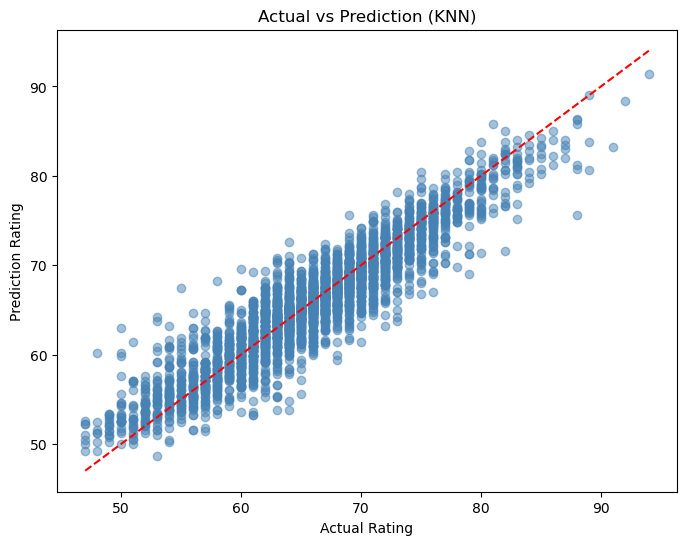

In [144]:
# These numbers tell you the model is good, but do not show you how and where it's good or bad. 
# The plot will shows where it's good or bad with perfect prediction line which actual and prediction rate is same.

min_val = y_test.min()
max_val = y_test.max()

plt.figure(figsize=(8,6))
plt.scatter(y_test, pred, alpha=0.5, color="steelblue")
plt.plot([min_val, max_val], [min_val, max_val], color="red", linestyle="--")
plt.xlabel("Actual Rating")
plt.ylabel("Prediction Rating")
plt.title("Actual vs Prediction (KNN)")
plt.show()

## Conclusions


This project successfully utilized a KNN Regression model to predict FIFA soccer players' overall rating values. 
The visualization of scatter plots comparing predicted values to the perfect prediction line demonstrates that the 
overall rating range of 60 to 80 is relatively accurate and stable, while the ranges of 50 to 60 and 80 to 90 show 
predictions that are slightly higher or lower than the actual values. An R-squared score of 0.86 indicates that the 
KNN Regression model successfully predicted FIFA player overall ratings with an 86% accuracy rate. 
Furthermore, the MAE (Mean Absolute Error) of 1.96 being close to the RMSE (Root Mean Squared Error) of 2.62 confirms 
that there are no extreme outlier predictions, demonstrating the model's overall consistency and reliability. 

###  References
   - Academic (if any)
   - Online (if any)
	

CISD 43 Module 5 KNN examples and web conference
CISD 43 Module 13 Example 7: MongoDB and KNN - FIFA Players dataset
Using Claude to visualize how the model predicted overall rate

### Credits

- If you use and/or adapt your code from existing projects, you must provide links and acknowldge the authors. 
> *This code is based on .... (if any)*

This project code is based on - Module 12 NoSQL Tutorial and MongoDB Example 2
                              - Module 13 Example 7: MongoDB and KNN - FIFA Players datases
                              - CISD 43 Web Conference 11

In [ ]:
# End of Project